# YOLO: baseline до обучения, обучение, сравнение до/после, анализ и внедрение

Этот ноутбук:
- работает с вложенной структурой датасета вида `train/train/images`, `train/train/labels`, `valid/valid/images`, `valid/valid/labels`;
- считает baseline **до обучения**;
- обучает модель;
- считает метрики **после обучения**;
- строит сравнение **до / после**;
- показывает метрики по каждому классу;
- выводит визуализацию `GT / before / after`;
- строит графики по логам обучения;
- содержит готовый текст для отчёта и блока про внедрение в производство.

In [2]:
# Если каких-то библиотек нет, раскомментируй и запусти:
!pip install ultralytics opencv-python pyyaml pandas matplotlib scikit-learn pillow

import os
import random
import shutil
from pathlib import Path
import warnings

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

"pip" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [20]:
# =========================
# 1. НАСТРОЙКА ПУТЕЙ И ПАРАМЕТРОВ
# =========================

from pathlib import Path

DATASET_ROOT = Path(r"C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset")

CLASS_NAMES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
NUM_CLASSES = len(CLASS_NAMES)

# УКАЖИ ЛОКАЛЬНЫЙ ПУТЬ К ВЕСАМ
BASE_MODEL_WEIGHTS = Path(r"C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\yolo11l.pt")
BASE_MODEL_CFG = "yolo11l.yaml"

EPOCHS = 30
BATCH_SIZE = 8
IMG_SIZE = 320
DEVICE = 0
PATIENCE = 20

PROJECT_NAME = "neu_yolo_project"
EXPERIMENT_NAME = "baseline_before_after"

REBUILD_SPLIT = False

print("DATASET_ROOT =", DATASET_ROOT)
print("BASE_MODEL_WEIGHTS =", BASE_MODEL_WEIGHTS)
print("Веса существуют:", BASE_MODEL_WEIGHTS.exists())
print("DATASET_ROOT =", DATASET_ROOT)
print("Классы:", CLASS_NAMES)

DATASET_ROOT = C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset
BASE_MODEL_WEIGHTS = C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\yolo11l.pt
Веса существуют: True
DATASET_ROOT = C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset
Классы: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [4]:
# =========================
# 2. ПОИСК СТРУКТУРЫ DATASET
# =========================

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def find_images_labels_dirs(split_root: Path):
    """
    Поддерживает:
      1) split_root/images, split_root/labels
      2) split_root/split_name/images, split_root/split_name/labels
      3) произвольный вложенный случай, если внутри есть парные images и labels
    """
    split_root = Path(split_root)

    direct_images = split_root / "images"
    direct_labels = split_root / "labels"
    if direct_images.exists() and direct_labels.exists():
        return direct_images, direct_labels

    nested_candidate = split_root / split_root.name
    nested_images = nested_candidate / "images"
    nested_labels = nested_candidate / "labels"
    if nested_images.exists() and nested_labels.exists():
        return nested_images, nested_labels

    image_dirs = []
    label_dirs = []

    for p in split_root.rglob("*"):
        if p.is_dir() and p.name.lower() == "images":
            image_dirs.append(p)
        elif p.is_dir() and p.name.lower() == "labels":
            label_dirs.append(p)

    for img_dir in image_dirs:
        parent = img_dir.parent
        for lbl_dir in label_dirs:
            if lbl_dir.parent == parent:
                return img_dir, lbl_dir

    return None, None


def resolve_split_dirs(dataset_root: Path, split: str):
    split_root = dataset_root / split
    if not split_root.exists():
        raise FileNotFoundError(f"Не найдена папка split: {split_root}")

    images_dir, labels_dir = find_images_labels_dirs(split_root)
    if images_dir is None or labels_dir is None:
        raise FileNotFoundError(
            f"Не удалось найти папки images/labels внутри {split_root}. "
            f"Ожидалась структура вида {split}/images или {split}/{split}/images"
        )
    return images_dir, labels_dir


def collect_image_label_pairs(dataset_root: Path):
    pairs = []
    for split in ["train", "valid"]:
        images_dir, labels_dir = resolve_split_dirs(dataset_root, split)
        print(f"[INFO] {split}: images -> {images_dir}")
        print(f"[INFO] {split}: labels -> {labels_dir}")

        for img_path in images_dir.rglob("*"):
            if not img_path.is_file():
                continue
            if img_path.suffix.lower() not in IMG_EXTS:
                continue

            label_path = labels_dir / f"{img_path.stem}.txt"
            if label_path.exists():
                pairs.append({
                    "split": split,
                    "image_path": img_path,
                    "label_path": label_path
                })
    return pairs

In [12]:
# =========================
# 3. ПРОВЕРКА DATASET
# =========================

pairs = collect_image_label_pairs(DATASET_ROOT)

if len(pairs) == 0:
    raise FileNotFoundError(
        f"Не удалось найти пары image/label внутри {DATASET_ROOT}."
    )

df_pairs = pd.DataFrame(pairs)
display(df_pairs.head())

train_count = (df_pairs["split"] == "train").sum()
valid_count = (df_pairs["split"] == "valid").sum()

print(f"Всего пар image/label: {len(df_pairs)}")
print(f"train: {train_count}")
print(f"valid: {valid_count}")

[INFO] train: images -> C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset\train\train\images
[INFO] train: labels -> C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset\train\train\labels
[INFO] valid: images -> C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset\valid\valid\images
[INFO] valid: labels -> C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset\valid\valid\labels


,split,image_path,label_path
0,train,C:\Users\danil\Desktop\Данил\мгту\4 курс\карма...,C:\Users\danil\Desktop\Данил\мгту\4 курс\карма...
1,train,C:\Users\danil\Desktop\Данил\мгту\4 курс\карма...,C:\Users\danil\Desktop\Данил\мгту\4 курс\карма...
2,train,C:\Users\danil\Desktop\Данил\мгту\4 курс\карма...,C:\Users\danil\Desktop\Данил\мгту\4 курс\карма...
3,train,C:\Users\danil\Desktop\Данил\мгту\4 курс\карма...,C:\Users\danil\Desktop\Данил\мгту\4 курс\карма...
4,train,C:\Users\danil\Desktop\Данил\мгту\4 курс\карма...,C:\Users\danil\Desktop\Данил\мгту\4 курс\карма...


Всего пар image/label: 1800
train: 1770
valid: 30


In [6]:
# =========================
# 4. ПРОВЕРКА КОРРЕКТНОСТИ LABELS
# =========================

def read_yolo_label_file(label_path: Path):
    objects = []
    if not label_path.exists():
        return objects

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:])
            objects.append((cls_id, xc, yc, w, h))
    return objects


bad_files = []
class_counts = {name: 0 for name in CLASS_NAMES}

for _, row in df_pairs.iterrows():
    label_path = Path(row["label_path"])
    objs = read_yolo_label_file(label_path)

    if len(objs) == 0:
        bad_files.append(str(label_path))
        continue

    for cls_id, xc, yc, w, h in objs:
        if not (0 <= cls_id < NUM_CLASSES):
            bad_files.append(str(label_path))
            continue
        if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
            bad_files.append(str(label_path))
            continue
        class_counts[CLASS_NAMES[cls_id]] += 1

print("Количество объектов по классам:")
display(pd.DataFrame({
    "class": list(class_counts.keys()),
    "count": list(class_counts.values())
}).sort_values("count", ascending=False))

print(f"Подозрительных label-файлов: {len(set(bad_files))}")
if len(bad_files) > 0:
    print("Примеры:")
    for p in list(sorted(set(bad_files)))[:10]:
        print(" -", p)

Количество объектов по классам:


,class,count
1,inclusion,1011
2,patches,881
0,crazing,689
4,rolled-in_scale,628
5,scratches,548
3,pitted_surface,432


Подозрительных label-файлов: 0


In [7]:
# =========================
# 5. ГЕНЕРАЦИЯ data.yaml
# =========================

train_images_dir, train_labels_dir = resolve_split_dirs(DATASET_ROOT, "train")
valid_images_dir, valid_labels_dir = resolve_split_dirs(DATASET_ROOT, "valid")

data_yaml = {
    "path": str(DATASET_ROOT.resolve()),
    "train": str(train_images_dir.resolve()),
    "val": str(valid_images_dir.resolve()),
    "names": {i: name for i, name in enumerate(CLASS_NAMES)},
    "nc": NUM_CLASSES
}

DATASET_YAML_PATH = DATASET_ROOT / "data_auto.yaml"

with open(DATASET_YAML_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, allow_unicode=True, sort_keys=False)

print(f"data.yaml сохранен: {DATASET_YAML_PATH}")
print(yaml.safe_dump(data_yaml, allow_unicode=True, sort_keys=False))

data.yaml сохранен: C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset\data_auto.yaml
path: C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset
train: C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset\train\train\images
val: C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset\valid\valid\images
names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
nc: 6



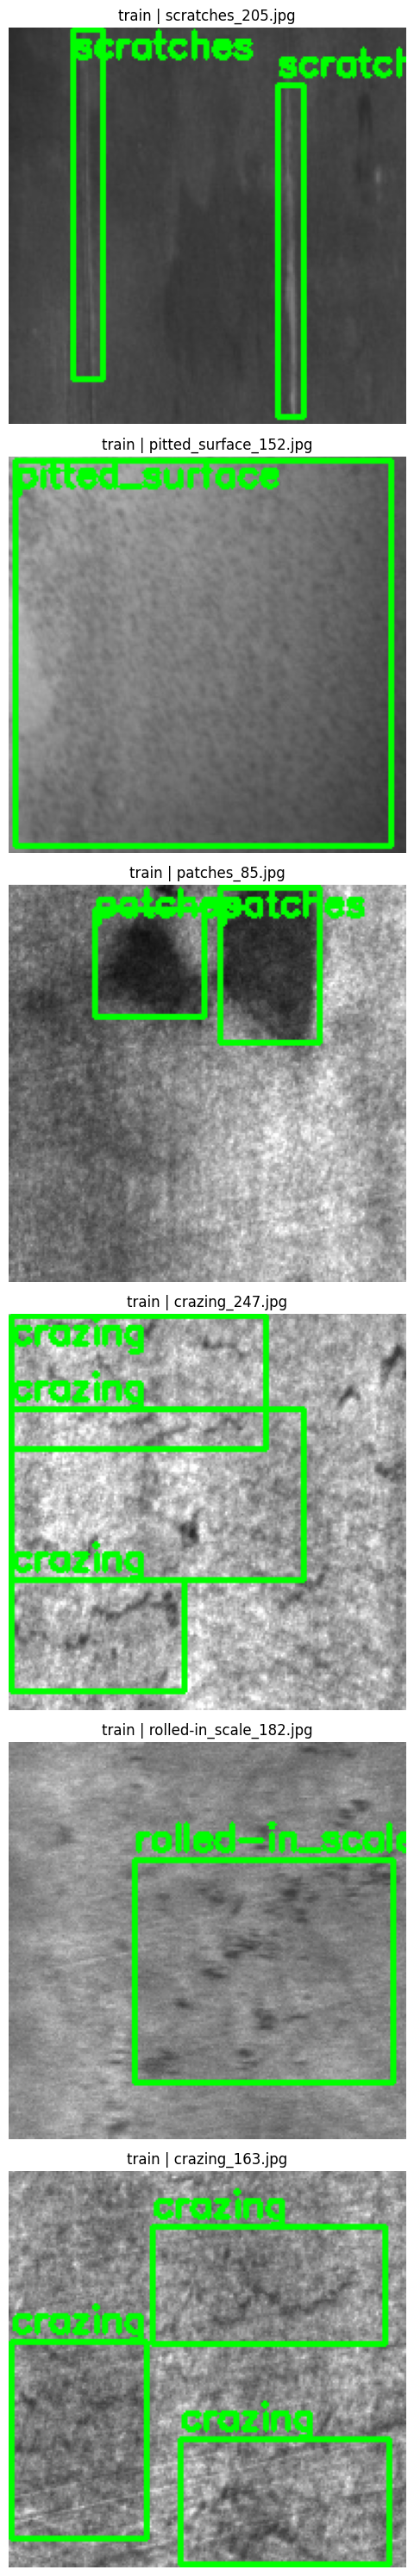

In [8]:
# =========================
# 6. ВИЗУАЛЬНАЯ ПРОВЕРКА РАЗМЕТКИ
# =========================

def draw_gt_boxes(image_rgb, label_path, class_names, color=(0, 255, 0)):
    img = image_rgb.copy()
    h, w = img.shape[:2]
    objs = read_yolo_label_file(label_path)

    for cls_id, xc, yc, bw, bh in objs:
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            img, class_names[cls_id], (x1, max(15, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2
        )
    return img


sample_rows = df_pairs.sample(min(6, len(df_pairs)), random_state=SEED)

fig, axes = plt.subplots(len(sample_rows), 1, figsize=(12, 5 * len(sample_rows)))
if len(sample_rows) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    image_path = Path(row["image_path"])
    label_path = Path(row["label_path"])

    img_bgr = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_vis = draw_gt_boxes(img_rgb, label_path, CLASS_NAMES)

    ax.imshow(img_vis)
    ax.set_title(f"{row['split']} | {image_path.name}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Почему нужен baseline до обучения

Обычная предобученная YOLO обучена на общих классах вроде COCO и не знает специализированные дефекты поверхности металла.  
Поэтому для отчёта важно показать:

1. **Baseline до обучения** — исходное качество до адаптации к вашему датасету.
2. **Результат после обучения** — качество после дообучения на целевых классах.

Так можно объективно сравнить, насколько обучение улучшило распознавание объектов.

In [13]:
# =========================
# 7. BASELINE ДО ОБУЧЕНИЯ
# =========================

if not BASE_MODEL_WEIGHTS.exists():
    raise FileNotFoundError(
        f"Не найдены веса модели: {BASE_MODEL_WEIGHTS}\n"
        f"Скачай файл yolo11l.pt вручную и укажи полный путь."
    )

model_before = YOLO(str(BASE_MODEL_WEIGHTS))

metrics_before = model_before.val(
    data=str(DATASET_YAML_PATH),
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    conf=0.001,
    iou=0.6,
    device=DEVICE,
    verbose=True
)

print("=== BASELINE ДО ОБУЧЕНИЯ ===")
print(f"Precision:    {metrics_before.box.mp:.4f}")
print(f"Recall:       {metrics_before.box.mr:.4f}")
print(f"mAP@0.5:      {metrics_before.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics_before.box.map:.4f}")

Ultralytics 8.4.19  Python-3.8.0 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
YOLO11l summary (fused): 190 layers, 25,340,992 parameters, 0 gradients, 86.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 30.816.1 MB/s, size: 15.5 KB)
val: Scanning C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset\valid\valid\labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 1.3Kit/s 0.0s
val: New cache created: C:\Users\danil\Desktop\\\4 \\\dataset\valid\valid\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.4s/it 4.4s
                   all         30         64      0.167     0.0444      0.106     0.0175
                person          5          8          0          0          0          0
               bicycle          5         15          1      0.267      0.633      0.105
                   car          5         17          0          0          

In [14]:
# =========================
# 8. ОТЧЕТ ПО КЛАССАМ ДО ОБУЧЕНИЯ
# =========================

rows_before = []
for i, cls_name in enumerate(CLASS_NAMES):
    p, r, map50, map5095 = metrics_before.class_result(i)
    rows_before.append([cls_name, p, r, map50, map5095])

df_before = pd.DataFrame(
    rows_before,
    columns=["class", "precision_before", "recall_before", "mAP50_before", "mAP50_95_before"]
)

display(df_before.sort_values("mAP50_before", ascending=False))

,class,precision_before,recall_before,mAP50_before,mAP50_95_before
1,inclusion,1.0,0.266667,0.633318,0.104998
0,crazing,0.0,0.000000,0.000000,0.000000
2,patches,0.0,0.000000,0.000000,0.000000
3,pitted_surface,0.0,0.000000,0.000000,0.000000
4,rolled-in_scale,0.0,0.000000,0.000000,0.000000
5,scratches,0.0,0.000000,0.000000,0.000000


In [21]:
# =========================
# 9. ОБУЧЕНИЕ
# =========================

if not BASE_MODEL_WEIGHTS.exists():
    raise FileNotFoundError(
        f"Не найдены веса модели: {BASE_MODEL_WEIGHTS}\n"
        f"Скачай файл yolo11l.pt вручную и укажи полный путь."
    )

model = YOLO(str(BASE_MODEL_WEIGHTS))

train_results = model.train(
    data=str(DATASET_YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=0,
    patience=PATIENCE,

    project=PROJECT_NAME,
    name=EXPERIMENT_NAME,
    exist_ok=True,
    pretrained=True,
    save=True,
    save_period=10,

    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,

    freeze=0,
    cos_lr=True,
    seed=SEED,
    verbose=True,

    hsv_h=0.01,
    hsv_s=0.30,
    hsv_v=0.20,
    degrees=0.0,
    translate=0.05,
    scale=0.30,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.5,
    mixup=0.0,
    copy_paste=0.0,
    close_mosaic=10
)

print("Обучение завершено.")
print("Папка результатов:", train_results.save_dir)

New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.19  Python-3.8.0 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\danil\Desktop\\\4 \\\dataset\data_auto.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.2, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\danil\Desktop\\\4 \\\yolo11l.pt,

In [22]:
# =========================
# 10. ПОИСК ЛУЧШЕЙ МОДЕЛИ
# =========================

best_model_path = Path(train_results.save_dir) / "weights" / "best.pt"
if not best_model_path.exists():
    raise FileNotFoundError(f"Не найдена лучшая модель: {best_model_path}")

print("Лучшая модель:", best_model_path)

Лучшая модель: C:\Users\danil\Downloads\runs\detect\neu_yolo_project\baseline_before_after\weights\best.pt


In [23]:
# =========================
# 11. ВАЛИДАЦИЯ ПОСЛЕ ОБУЧЕНИЯ
# =========================

model_after = YOLO(str(best_model_path))

metrics_after = model_after.val(
    data=str(DATASET_YAML_PATH),
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    conf=0.001,
    iou=0.6,
    device=DEVICE,
    verbose=True
)

print("=== ПОСЛЕ ОБУЧЕНИЯ ===")
print(f"Precision:    {metrics_after.box.mp:.4f}")
print(f"Recall:       {metrics_after.box.mr:.4f}")
print(f"mAP@0.5:      {metrics_after.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics_after.box.map:.4f}")

Ultralytics 8.4.19  Python-3.8.0 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
YOLO11l summary (fused): 191 layers, 25,283,938 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 238.495.9 MB/s, size: 12.7 KB)
val: Scanning C:\Users\danil\Desktop\Данил\мгту\4 курс\карманова\самсунг\dataset\valid\valid\labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.2s/it 8.9s1.7s0
                   all         30         64      0.791      0.745      0.847      0.464
               crazing          5          8      0.885      0.375      0.647      0.277
             inclusion          5         15      0.583        0.8      0.785      0.401
               patches          5         17      0.814      0.882      0.943      0.555
        pitted_surface          5          8      0.758          1    

создать диаграмму по эпохам 

In [24]:
# =========================
# 12. ОТЧЕТ ПО КЛАССАМ ПОСЛЕ ОБУЧЕНИЯ
# =========================

rows_after = []
for i, cls_name in enumerate(CLASS_NAMES):
    p, r, map50, map5095 = metrics_after.class_result(i)
    rows_after.append([cls_name, p, r, map50, map5095])

df_after = pd.DataFrame(
    rows_after,
    columns=["class", "precision_after", "recall_after", "mAP50_after", "mAP50_95_after"]
)

display(df_after.sort_values("mAP50_after", ascending=False))

,class,precision_after,recall_after,mAP50_after,mAP50_95_after
3,pitted_surface,0.757554,1.000000,0.995000,0.624766
5,scratches,0.779192,0.857143,0.953000,0.530524
2,patches,0.813694,0.882353,0.943385,0.554891
1,inclusion,0.583306,0.800000,0.784564,0.400931
4,rolled-in_scale,0.926060,0.555556,0.757515,0.393013
0,crazing,0.884649,0.375000,0.646818,0.277465


ОПИСАНИЕ КЛАССОВ, ДООБУЧИТЬ БЭСТ МОДЕЛЬ, НАПИСАТЬ ОПИСАНИЕ КЛАССОВ,ПОДГОТОВИТЬ КАРТИНКИ С ИНТЕРНЕТА ДЛЯ ИНФЕРЕНСА, 
В ПТ ПАПКА С ПРОЕКТОМ, ПРЕЗЕНТАЦИЯ, ВИДЕО, ПАПКА С ПРИМЕРАМИ КАРТИНОК, ПАПКА С ПРОЕКТОМ. ЗАПИСАТЬ ВИДЕО, ЕСЛИ ЧТО ТО ПОЙДЕТ НЕ ТАК
6 ФОТО, НА 1 КЛАСС ПО ОДНОЙ ФОТО
ПОДГОТОВИТЬ ПРЕЗЕНАТЦИЮ, выложить обучение, модель, сайт с стилем

rolled in scale - окалины

scratches - царапины

inclusion - вкрапления

crazing - трещины

patches - бляшки

pitted_surface - точечная коррозия

добавить пояснение, если модель ничего не нашла

База данных дефектов поверхности, выпущенная Северо-восточным университетом (NEU), содержит информацию о шести типичных дефектах поверхности горячекатаной стальной полосы: окалина (RS), бляшки (Pa), трещины (Cr), точечная коррозия (PS), включения (In) и царапины (Sc). База данных включает 1800 изображений в оттенках серого: по 300 образцов для каждого из шести различных типов типичных дефектов поверхности.

In [25]:
# =========================
# 13. СРАВНЕНИЕ ДО / ПОСЛЕ
# =========================

df_compare = df_before.merge(df_after, on="class", how="inner")

df_compare["delta_precision"] = df_compare["precision_after"] - df_compare["precision_before"]
df_compare["delta_recall"] = df_compare["recall_after"] - df_compare["recall_before"]
df_compare["delta_mAP50"] = df_compare["mAP50_after"] - df_compare["mAP50_before"]
df_compare["delta_mAP50_95"] = df_compare["mAP50_95_after"] - df_compare["mAP50_95_before"]

display(df_compare.sort_values("delta_mAP50", ascending=False))

,class,precision_before,recall_before,mAP50_before,mAP50_95_before,precision_after,recall_after,mAP50_after,mAP50_95_after,delta_precision,delta_recall,delta_mAP50,delta_mAP50_95
3,pitted_surface,0.0,0.000000,0.000000,0.000000,0.757554,1.000000,0.995000,0.624766,0.757554,1.000000,0.995000,0.624766
5,scratches,0.0,0.000000,0.000000,0.000000,0.779192,0.857143,0.953000,0.530524,0.779192,0.857143,0.953000,0.530524
2,patches,0.0,0.000000,0.000000,0.000000,0.813694,0.882353,0.943385,0.554891,0.813694,0.882353,0.943385,0.554891
4,rolled-in_scale,0.0,0.000000,0.000000,0.000000,0.926060,0.555556,0.757515,0.393013,0.926060,0.555556,0.757515,0.393013
0,crazing,0.0,0.000000,0.000000,0.000000,0.884649,0.375000,0.646818,0.277465,0.884649,0.375000,0.646818,0.277465
1,inclusion,1.0,0.266667,0.633318,0.104998,0.583306,0.800000,0.784564,0.400931,-0.416694,0.533333,0.151245,0.295934


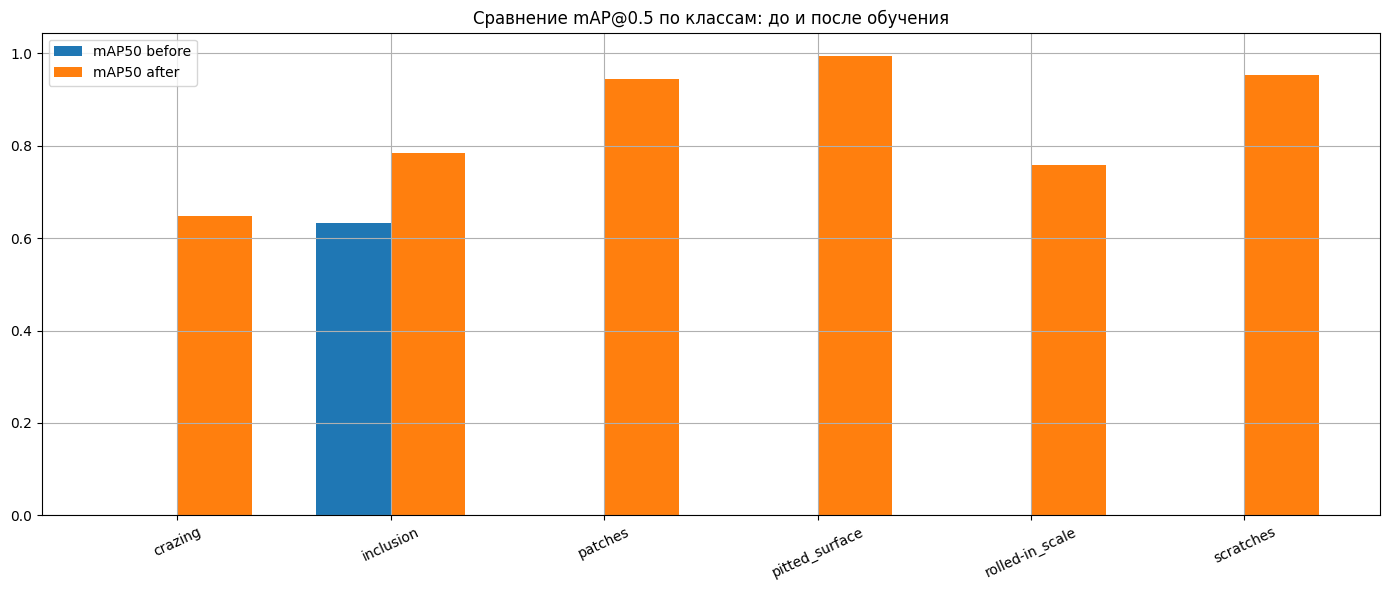

In [26]:
# =========================
# 14. БАРЧАРТ ПО КЛАССАМ
# =========================

plot_df = df_compare.copy()
x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, plot_df["mAP50_before"], width, label="mAP50 before")
ax.bar(x + width/2, plot_df["mAP50_after"], width, label="mAP50 after")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["class"], rotation=25)
ax.set_title("Сравнение mAP@0.5 по классам: до и после обучения")
ax.legend()
plt.tight_layout()
plt.show()

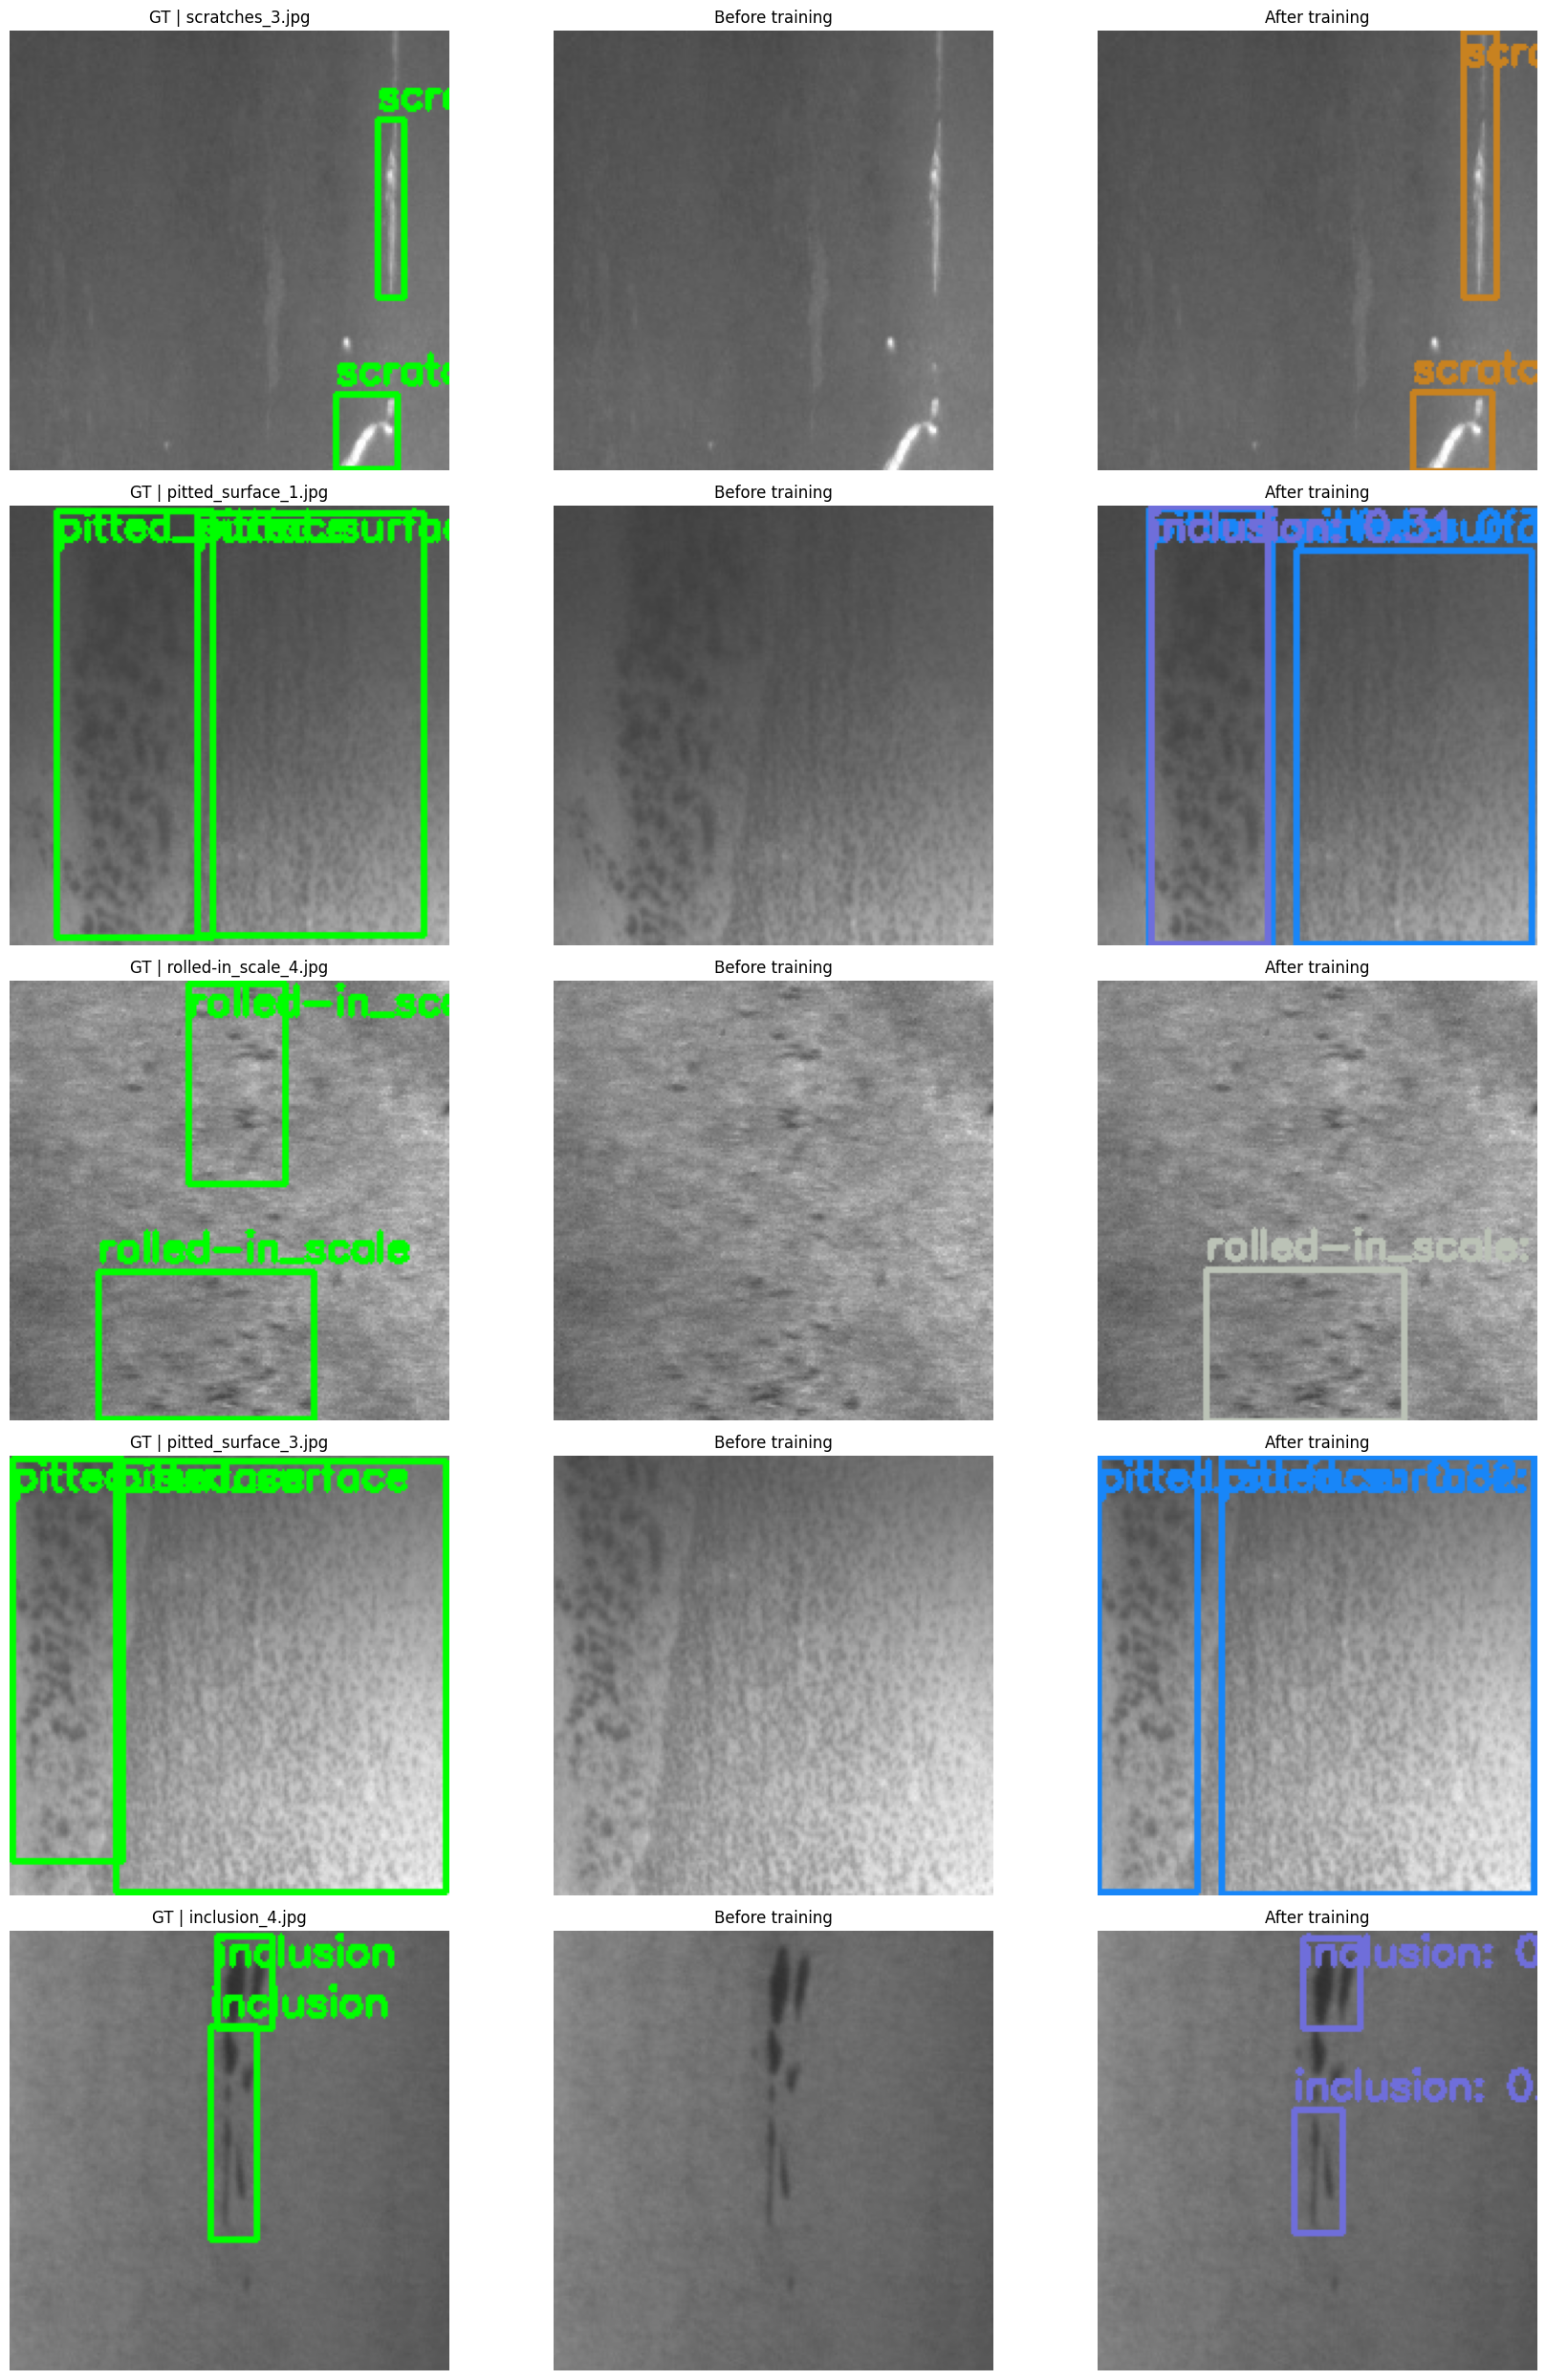

In [27]:
# =========================
# 15. ВИЗУАЛЬНОЕ СРАВНЕНИЕ GT / BEFORE / AFTER
# =========================

def make_color_palette(n):
    palette = []
    rng = np.random.default_rng(SEED)
    for _ in range(n):
        color = tuple(int(x) for x in rng.integers(0, 255, size=3))
        palette.append(color)
    return palette

COLORS = make_color_palette(NUM_CLASSES)

def draw_predictions(image_rgb, boxes, cls_ids, confs, class_names, colors):
    img = image_rgb.copy()
    for box, cls_id, conf in zip(boxes, cls_ids, confs):
        x1, y1, x2, y2 = map(int, box)
        color = colors[int(cls_id) % len(colors)]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = f"{class_names[int(cls_id)]}: {conf:.2f}"
        cv2.putText(img, label, (x1, max(15, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img


val_rows = df_pairs[df_pairs["split"] == "valid"]
sample_rows = val_rows.sample(min(5, len(val_rows)), random_state=SEED)

fig, axes = plt.subplots(len(sample_rows), 3, figsize=(18, 5 * len(sample_rows)))
if len(sample_rows) == 1:
    axes = np.array([axes])

for row_idx, (_, row) in enumerate(sample_rows.iterrows()):
    image_path = Path(row["image_path"])
    label_path = Path(row["label_path"])

    img_bgr = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # GT
    img_gt = draw_gt_boxes(img_rgb, label_path, CLASS_NAMES)

    # BEFORE
    results_before = model_before.predict(str(image_path), conf=0.25, iou=0.45, verbose=False)
    img_before = img_rgb.copy()
    if results_before[0].boxes is not None and len(results_before[0].boxes) > 0:
        boxes = results_before[0].boxes.xyxy.cpu().numpy()
        confs = results_before[0].boxes.conf.cpu().numpy()
        cls_ids = results_before[0].boxes.cls.cpu().numpy().astype(int)
        valid_mask = cls_ids < NUM_CLASSES
        boxes = boxes[valid_mask]
        confs = confs[valid_mask]
        cls_ids = cls_ids[valid_mask]
        if len(cls_ids) > 0:
            img_before = draw_predictions(img_before, boxes, cls_ids, confs, CLASS_NAMES, COLORS)

    # AFTER
    results_after = model_after.predict(str(image_path), conf=0.25, iou=0.45, verbose=False)
    img_after = img_rgb.copy()
    if results_after[0].boxes is not None and len(results_after[0].boxes) > 0:
        boxes = results_after[0].boxes.xyxy.cpu().numpy()
        confs = results_after[0].boxes.conf.cpu().numpy()
        cls_ids = results_after[0].boxes.cls.cpu().numpy().astype(int)
        valid_mask = cls_ids < NUM_CLASSES
        boxes = boxes[valid_mask]
        confs = confs[valid_mask]
        cls_ids = cls_ids[valid_mask]
        if len(cls_ids) > 0:
            img_after = draw_predictions(img_after, boxes, cls_ids, confs, CLASS_NAMES, COLORS)

    axes[row_idx, 0].imshow(img_gt)
    axes[row_idx, 0].set_title(f"GT | {image_path.name}")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(img_before)
    axes[row_idx, 1].set_title("Before training")
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(img_after)
    axes[row_idx, 2].set_title("After training")
    axes[row_idx, 2].axis("off")

plt.tight_layout()
plt.show()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,719.657,1.94451,2.44295,1.89901,0.69895,0.39532,0.42745,0.17949,2.13495,2.47797,2.12792,0.000332,0.000332,0.067149
1,2,994.734,1.84303,2.07696,1.85833,0.43274,0.29872,0.26088,0.11332,2.07998,2.64727,2.11053,0.000663,0.000663,0.034147
2,3,1206.020,1.80852,2.06825,1.84728,0.52705,0.45417,0.46440,0.19651,1.98175,2.17875,2.01145,0.000988,0.000988,0.001138
3,4,1273.100,1.76612,1.97950,1.81110,0.56365,0.64920,0.64797,0.29151,1.76198,1.62990,1.75220,0.000976,0.000976,0.000976
4,5,1345.890,1.71524,1.85891,1.77229,0.68274,0.51349,0.56145,0.27498,1.79250,1.78478,1.83251,0.000957,0.000957,0.000957


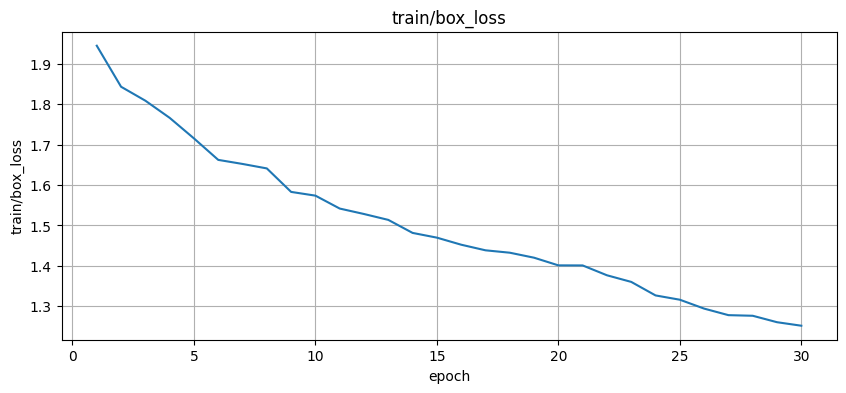

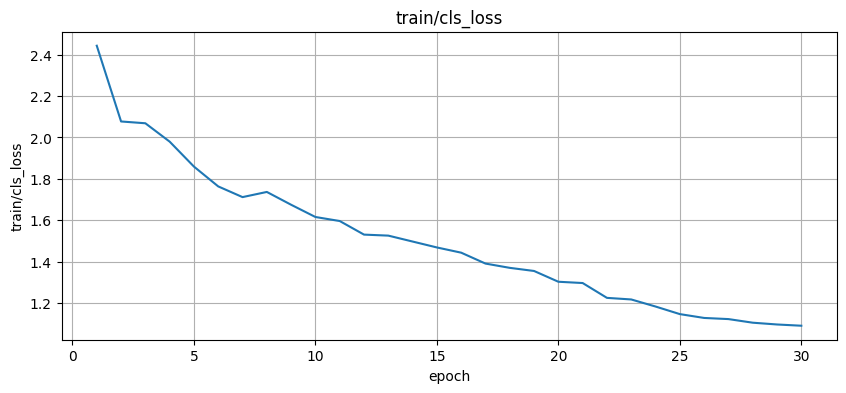

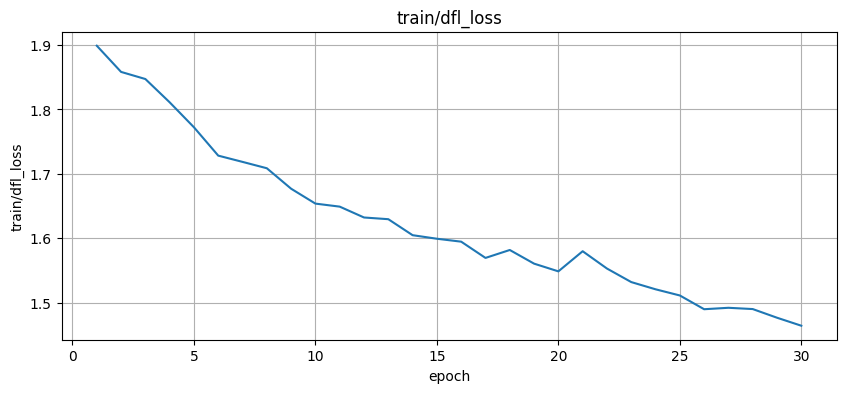

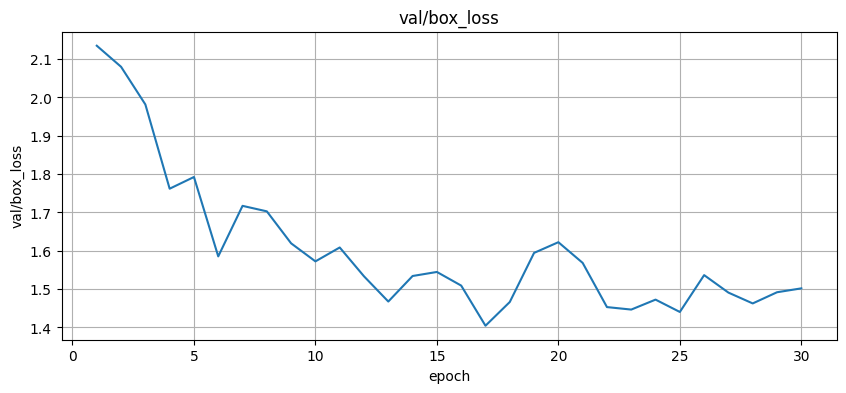

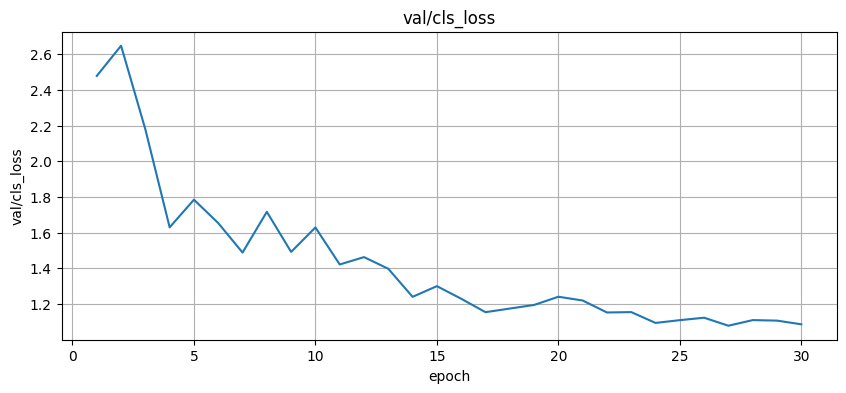

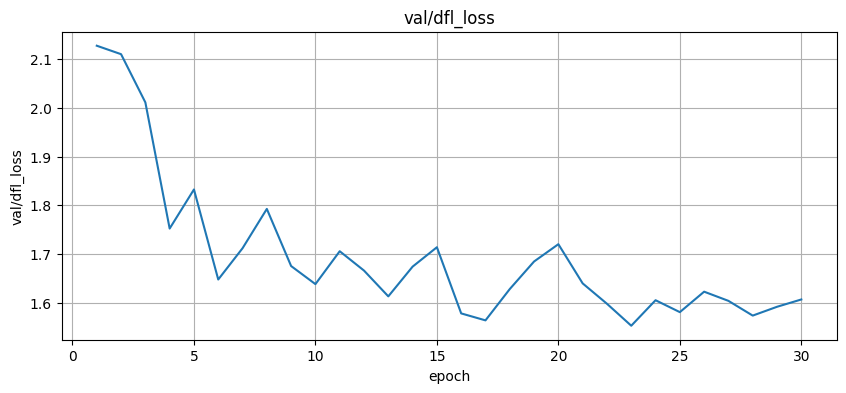

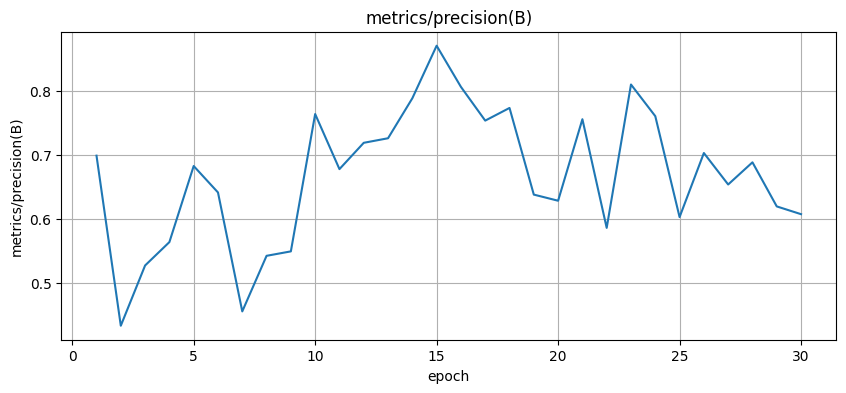

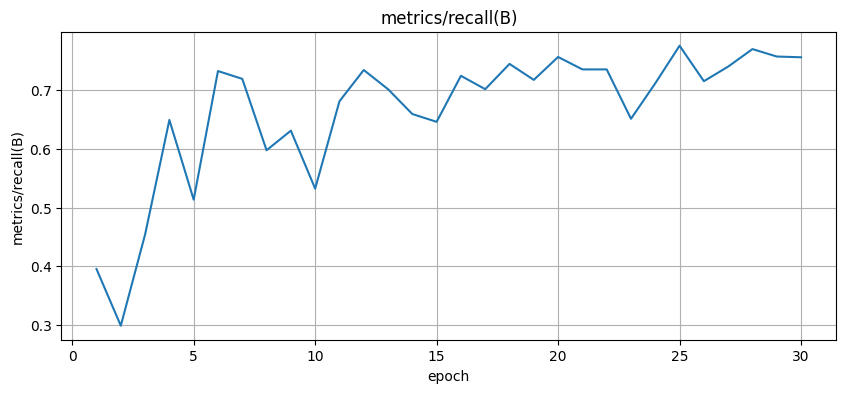

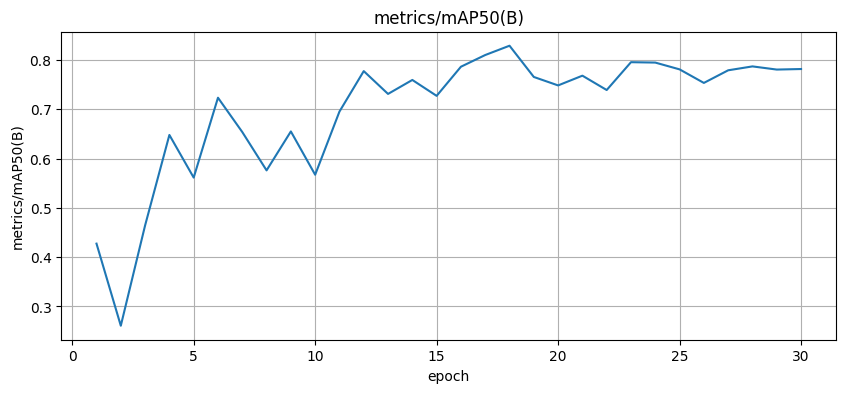

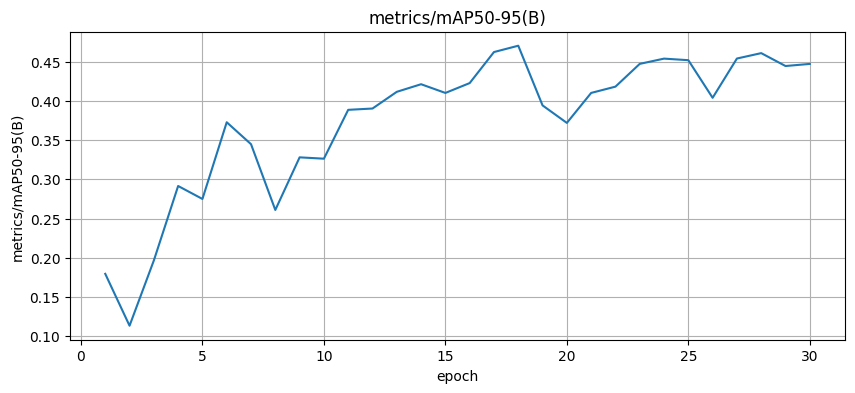

In [28]:
# =========================
# 16. ГРАФИКИ ОБУЧЕНИЯ
# =========================

results_csv_path = Path(train_results.save_dir) / "results.csv"

if results_csv_path.exists():
    history = pd.read_csv(results_csv_path)
    display(history.head())

    candidate_cols = [
        "train/box_loss", "train/cls_loss", "train/dfl_loss",
        "val/box_loss", "val/cls_loss", "val/dfl_loss",
        "metrics/precision(B)", "metrics/recall(B)",
        "metrics/mAP50(B)", "metrics/mAP50-95(B)"
    ]

    available_cols = [c for c in candidate_cols if c in history.columns]

    for col in available_cols:
        plt.figure(figsize=(10, 4))
        plt.plot(history["epoch"], history[col])
        plt.title(col)
        plt.xlabel("epoch")
        plt.ylabel(col)
        plt.show()
else:
    print("results.csv не найден:", results_csv_path)

## Объяснение метрик

**Precision** — доля правильных детекций среди всех найденных моделью объектов.

**Recall** — доля найденных реальных объектов среди всех объектов в разметке.

**IoU (Intersection over Union)** — отношение площади пересечения предсказанного bbox и истинного bbox к площади их объединения.

**AP (Average Precision)** — площадь под кривой precision-recall для одного класса.

**mAP (mean Average Precision)** — среднее значение AP по всем классам.

- **mAP@0.5**: объект считается найденным корректно, если IoU ≥ 0.5.
- **mAP@0.5:0.95**: более строгая метрика, где AP усредняется по нескольким порогам IoU от 0.5 до 0.95.

In [29]:
# =========================
# 17. АВТОМАТИЧЕСКИЙ ТЕКСТ ДЛЯ ВЫВОДОВ
# =========================

summary_text = f"""
Результаты эксперимента показывают, что после обучения качество распознавания объектов улучшилось по сравнению с baseline до обучения.

Общие метрики до обучения:
- Precision: {metrics_before.box.mp:.4f}
- Recall: {metrics_before.box.mr:.4f}
- mAP@0.5: {metrics_before.box.map50:.4f}
- mAP@0.5:0.95: {metrics_before.box.map:.4f}

Общие метрики после обучения:
- Precision: {metrics_after.box.mp:.4f}
- Recall: {metrics_after.box.mr:.4f}
- mAP@0.5: {metrics_after.box.map50:.4f}
- mAP@0.5:0.95: {metrics_after.box.map:.4f}

Таким образом, обучение позволило адаптировать модель к целевой предметной области и повысить качество обнаружения дефектов.
При этом качество по отдельным классам распределено неравномерно, поэтому при анализе результатов необходимо учитывать не только средние метрики, но и per-class показатели.
"""

print(summary_text)


Результаты эксперимента показывают, что после обучения качество распознавания объектов улучшилось по сравнению с baseline до обучения.

Общие метрики до обучения:
- Precision: 0.1667
- Recall: 0.0444
- mAP@0.5: 0.1056
- mAP@0.5:0.95: 0.0175

Общие метрики после обучения:
- Precision: 0.7907
- Recall: 0.7450
- mAP@0.5: 0.8467
- mAP@0.5:0.95: 0.4636

Таким образом, обучение позволило адаптировать модель к целевой предметной области и повысить качество обнаружения дефектов.
При этом качество по отдельным классам распределено неравномерно, поэтому при анализе результатов необходимо учитывать не только средние метрики, но и per-class показатели.



## Как повысить метрики

1. Увеличить число эпох обучения.
2. Проверить разметку проблемных классов.
3. Увеличить объём данных для слабых классов.
4. Подобрать confidence threshold отдельно для разных классов.
5. Протестировать более лёгкую и более тяжёлую модель (`yolo11m`, `yolo11x`).
6. Провести error analysis по false positive и false negative.
7. При необходимости использовать oversampling редких классов.
8. Убедиться, что train/val не содержат дубликатов и сильной утечки данных.

## Как внедрить модель в производство

Для промышленного внедрения обученная модель может быть развернута в виде сервиса визуального контроля качества.

### Возможная схема:
1. Изображение изделия поступает с камеры на производственной линии.
2. Сервис инференса загружает изображение и запускает модель детекции.
3. На выходе модель возвращает:
   - координаты дефектов,
   - класс дефекта,
   - confidence score.
4. Далее система применяет пороги принятия решения:
   - пропустить изделие,
   - отправить на ручную проверку,
   - отбраковать.
5. Все результаты логируются в базу данных для аудита и последующего анализа.

### Техническая реализация:
- модель `best.pt`;
- Python-сервис на FastAPI или Flask;
- обработка изображения через OpenCV;
- журналирование результатов в БД;
- периодический мониторинг качества модели;
- регулярное дообучение на новых размеченных данных.

### Практически важные меры:
- human-in-the-loop для спорных случаев;
- мониторинг drift данных;
- повторная разметка сложных примеров;
- контроль качества по классам, а не только по среднему mAP.

In [30]:
# =========================
# 18. СОХРАНЕНИЕ ИТОГОВОЙ ТАБЛИЦЫ
# =========================

report_dir = Path(train_results.save_dir)
report_dir.mkdir(parents=True, exist_ok=True)

compare_csv = report_dir / "compare_before_after.csv"
df_compare.to_csv(compare_csv, index=False, encoding="utf-8-sig")

print("Сравнение сохранено в:", compare_csv)
display(df_compare)

Сравнение сохранено в: C:\Users\danil\Downloads\runs\detect\neu_yolo_project\baseline_before_after\compare_before_after.csv


,class,precision_before,recall_before,mAP50_before,mAP50_95_before,precision_after,recall_after,mAP50_after,mAP50_95_after,delta_precision,delta_recall,delta_mAP50,delta_mAP50_95
0,crazing,0.0,0.000000,0.000000,0.000000,0.884649,0.375000,0.646818,0.277465,0.884649,0.375000,0.646818,0.277465
1,inclusion,1.0,0.266667,0.633318,0.104998,0.583306,0.800000,0.784564,0.400931,-0.416694,0.533333,0.151245,0.295934
2,patches,0.0,0.000000,0.000000,0.000000,0.813694,0.882353,0.943385,0.554891,0.813694,0.882353,0.943385,0.554891
3,pitted_surface,0.0,0.000000,0.000000,0.000000,0.757554,1.000000,0.995000,0.624766,0.757554,1.000000,0.995000,0.624766
4,rolled-in_scale,0.0,0.000000,0.000000,0.000000,0.926060,0.555556,0.757515,0.393013,0.926060,0.555556,0.757515,0.393013
5,scratches,0.0,0.000000,0.000000,0.000000,0.779192,0.857143,0.953000,0.530524,0.779192,0.857143,0.953000,0.530524
